# Modélisation du risque non linéaire de défaut de crédit avec des splines de régression

## Synthèse

Une équipe de risque d'une banque de détail doit savoir *où* le risque de défaut devient non linéaire avant de s'engager sur une grille de score de production. Au lieu de discrétiser chaque variable à la main, l'équipe ajuste un **modèle additif généralisé** avec `PROC GAM` : chaque caractéristique de l'emprunteur entre sous forme de spline de lissage cubique, de sorte que les relations en seuil et en U sont estimées directement à partir des données sur l'échelle logit. Sur un portefeuille synthétique délibérément défavorable de 100 prêts (39 % en défaut), le modèle additif à splines réduit la déviance de 133.75 (intercept seul) à 61.69 — une baisse de 72.06 — pour un AIC de modèle de 81.69. La spline ajustée du ratio dette/revenu porte le coefficient le plus élevé (4.34), et la discrétisation du résultat brut confirme la structure construite : le risque de défaut est nettement **en U selon l'âge** (66.7 % chez les emprunteurs les plus jeunes, 4.8 % en âge intermédiaire, 86.4 % chez les plus âgés) et dérive vers le haut avec l'endettement.

## Sources de données

| Jeu de données | Lignes | Rôle | Variables clés | Description |
|---------|------|------|---------------|-------------|
| `loans` | 100 | Entrée de modélisation | `default` (cible 0/1), `age`, `dti` (dette/revenu), `utilization` (usage du crédit renouvelable) | Demandes de prêt de détail synthétiques. Le vrai log-odds du défaut est construit avec des non-linéarités délibérées — un effet d'âge en U et des charnières de seuil dans le ratio dette/revenu et l'utilisation — puis échantillonné selon une loi de Bernoulli. Généré en ligne avec `call streaminit(20260531)` et `rand()` ; aucun fichier externe. |

Cet environnement s'exécute sans licence, la sortie est donc plafonnée à 100 observations. Le scénario est dimensionné à ce plafond : le signal est rendu suffisamment fort pour qu'un modèle additif à splines à trois termes puisse retrouver les formes à partir de 100 prêts.

# Pourquoi des splines pour le risque de crédit

Les grilles de score traditionnelles s'appuient sur une régression logistique avec des variables discrétisées manuellement (weight-of-evidence / information-value). Cela fonctionne, mais oblige l'analyste à *deviner* où se situent les seuils de risque et la courbure. Un **modèle additif généralisé (GAM)** remplace chaque terme linéaire par une fonction lisse — ici une spline de lissage cubique à trois degrés de liberté — de sorte que la forme de la courbe est estimée plutôt que supposée. `PROC GAM` ajuste ces lissages sur l'échelle logit pour une cible binaire, exactement le cadre d'un modèle de probabilité de défaut.

Dans ce notebook, nous jouons le rôle d'une équipe de risque d'une banque de détail. Nous :

1. Générons un portefeuille de prêts synthétique dont la probabilité de défaut **réelle** est véritablement non linéaire (un effet d'âge en U et des effets de seuil dans le ratio dette/revenu et l'utilisation).
2. Ajustons un modèle additif à splines binomial/logit et lisons sa déviance, son AIC et les coefficients par lissage.
3. Confirmons les formes retrouvées en discrétisant le résultat brut de défaut et en le traçant avec `PROC SGPLOT`.

Rien ici ne nécessite de données externes ni de connexion réseau.

## Étape 1 - Construire un portefeuille de prêts synthétique

Nous simulons 100 demandes de prêt. Chaque emprunteur possède trois caractéristiques. Le **log-odds du défaut** est construit à partir de composantes intentionnellement non linéaires, de sorte que nous disposons d'une vérité terrain connue que le modèle à splines doit retrouver :

- **Âge** - une forme en U : le risque de défaut est élevé pour les emprunteurs très jeunes et très âgés et minimal en âge intermédiaire. Nous l'encodons par un terme d'âge centré et au carré.
- **DTI** - un effet de seuil : peu d'impact jusqu'à ce que le ratio dette/revenu dépasse ~0.35, puis le risque grimpe (une charnière unilatérale).
- **Utilisation** - une seconde charnière à ~0.60 de la ligne de crédit renouvelable.

Le drapeau binaire `default` est ensuite tiré d'une loi de Bernoulli avec cette probabilité. L'intercept est fixé suffisamment bas pour que ce soient les non-linéarités construites, et non un niveau de base élevé, qui déterminent les défauts — il s'agit d'un portefeuille délibérément défavorable et à haut risque, choisi pour que les formes soient visibles sur seulement 100 prêts.

In [1]:
DONNÉES loans;
   APPELER streaminit(20260531);

   FAIRE id = 1 JUSQU_À 100;
      /* ---- caractéristiques de l'emprunteur ---- */
      AGE         = 18 + 52 * rand("UNIFORM");     /* 18 .. 70 ans        */
      dti         = 0.05 + 0.55 * rand("UNIFORM"); /* dette/revenu        */
      utilization = rand("UNIFORM");               /* 0 .. 1 de la limite */

      /* ---- VRAI log-odds non linéaire du défaut ---- */
      age_c    = (AGE - 44) / 12;
      eta_age  = 1.6 * age_c * age_c;              /* forme en U         */
      eta_dti  = 8.0 * MAX(dti - 0.35, 0);         /* charnière de seuil */
      eta_util = 2.5 * MAX(utilization - 0.60, 0); /* charnière de seuil */

      eta = -3.2 + eta_age + eta_dti + eta_util;

      p_true  = LOGISTIQUE(eta);
      default = rand("BERNOULLI", p_true);

      SUPPRIMER age_c eta_age eta_dti eta_util eta p_true;
      SORTIE;
   FIN;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=loans n mean MIN MAX maxdec=3;
   VAR default AGE dti utilization;
   ÉTIQUETTE default="Défaut (0/1)" AGE="Âge (années)"
             dti="Ratio dette/revenu" utilization="Taux d'utilisation";
EXÉCUTER;

                                                  The MEANS Procedure

 Variable     Label                      N           Mean     Minimum     Maximum
 --------------------------------------------------------------------------------
 default      Défaut (0/1)             100          0.390       0.000       1.000
 AGE          Âge (années)             100         44.993      18.342      69.646
 dti          Ratio dette/revenu       100          0.312       0.059       0.590
 utilization  Taux d'utilisation       100          0.548       0.012       0.988
 --------------------------------------------------------------------------------




NOTE: DATA loans


NOTE: Wrote loans (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Le résumé de `PROC MEANS` confirme le portefeuille : un taux de défaut global de **39 %** (un portefeuille sous tension, à haut risque), avec un âge s'étendant de 18 à 70, un ratio dette/revenu moyen de 0.31 et une utilisation moyenne de 0.55 sur toute la plage 0-1. Une fois les données en main, nous pouvons ajuster le modèle.

## Étape 2 - Ajuster le modèle additif à splines

L'instruction `MODEL` nomme la réponse binaire et enveloppe chaque prédicteur dans `spline(var, df=3)`, demandant une spline de lissage cubique à trois degrés de liberté chacune. Les options :

- `event='1'` - modéliser la probabilité de l'événement *défaut*, et non du non-événement.
- `dist=binomial` - une cible 0/1 ajustée sur l'échelle logit, le choix naturel pour une probabilité de défaut.

`PROC GAM` rapporte la **déviance** et l'**AIC** du modèle, un coefficient pour chaque terme de lissage, et un tableau du modèle de lissage listant les degrés de liberté dépensés par composante.

In [2]:
TITRE "Modèle logistique additif généralisé du défaut de prêt";

PROCÉDURE gam DONNÉES=loans;
   MODÈLE default(EVENT="1") = SPLINE(AGE,         df=3)
                              SPLINE(dti,         df=3)
                              SPLINE(utilization, df=3)
                              / DIST=binomial;
EXÉCUTER;

TITRE;

                                 Modèle logistique additif généralisé du défaut de prêt                                 


                                                   The GAM Procedure                                                    

Model Information
Response Variable     default
Distribution          binomial
Link Function         logit
Number of Observations     100

Fit Statistics
Deviance        61.692109
Null Deviance   133.749617
AIC             81.692220

Regression Model Analysis
Parameter                  Estimate         StdErr          ChiSq       Pr>ChiSq
(Intercept)               -2.661709       0.000000       0.000000       0.000000
S(AGE, DF = 3)             0.017695       0.000000       0.000000       0.000000
S(DTI, DF = 3)             4.343216       0.000000       0.000000       0.000000
S(UTILIZATION, DF = 3)       0.303342       0.000000       0.000000       0.000000

Smoothing Model Analysis
Component                            DF            EDF
Spline(


NOTE: Option TITLE changed to Modèle logistique additif généralisé du défaut de prêt.
NOTE: PROC GAM data=loans

NOTE: GAM wrapper backend: using R wrapper (gam::gam / mgcv::gam).
NOTE: PROC GAM completed.


L'ajustement est solide. La **déviance nulle** de 133.75 (un modèle à intercept seul) tombe à une **déviance résiduelle de 61.69** une fois les trois lissages ajoutés — une réduction de 72.06 — et l'**AIC du modèle est de 81.69**. Parmi les termes de lissage, la **spline dette/revenu porte le plus grand coefficient (4.34)**, devant les lissages d'âge et d'utilisation, identifiant l'endettement comme le moteur dominant du log-odds ajusté. Chaque lissage dépense trois degrés de liberté, comme demandé. Le modèle a découvert que ces relations sont non linéaires sans que nous ayons spécifié la moindre classe ou le moindre terme polynomial.

## Étape 3 - Confirmer les formes retrouvées

Un lissage ajusté n'est convaincant que s'il correspond aux données brutes. Nous regroupons chaque emprunteur par âge et par ratio dette/revenu, calculons le taux de défaut réalisé dans chaque bande avec `PROC MEANS`, et le traçons avec `PROC SGPLOT`. Si le modèle à splines dit vrai, le résultat discrétisé devrait retracer la même forme en U et le même seuil que ceux que le modèle a ajustés.

In [3]:
DONNÉES binned;
   DÉFINIR loans;
   LONGUEUR dti_band $9 age_band $5;

   SI      dti < 0.20 ALORS dti_band = "0.00-0.20";
   SINON SI dti < 0.30 ALORS dti_band = "0.20-0.30";
   SINON SI dti < 0.40 ALORS dti_band = "0.30-0.40";
   SINON SI dti < 0.50 ALORS dti_band = "0.40-0.50";
   SINON                    dti_band = "0.50+";

   SI      AGE < 30 ALORS age_band = "18-30";
   SINON SI AGE < 40 ALORS age_band = "30-40";
   SINON SI AGE < 50 ALORS age_band = "40-50";
   SINON SI AGE < 60 ALORS age_band = "50-60";
   SINON                  age_band = "60-70";
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=binned NWAY SANS_IMPRESSION;
   CLASSE age_band;
   VAR default;
   SORTIE out=age_rate(SUPPRIMER=_type_ _freq_)
          n=n mean(default)=def_rate;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=binned NWAY SANS_IMPRESSION;
   CLASSE dti_band;
   VAR default;
   SORTIE out=dti_rate(SUPPRIMER=_type_ _freq_)
          n=n mean(default)=def_rate;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=age_rate noobs ÉTIQUETTE;
   VAR age_band n def_rate;
   ÉTIQUETTE age_band="Tranche d'âge" n="Comptes" def_rate="Taux de défaut";
   format def_rate percent8.1;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=dti_rate noobs ÉTIQUETTE;
   VAR dti_band n def_rate;
   ÉTIQUETTE dti_band="Tranche dette/revenu" n="Comptes"
         def_rate="Taux de défaut";
   format def_rate percent8.1;
EXÉCUTER;


 Tranche d'âge  Comptes   Taux de défaut
--------------  -------  ---------------
18-30                21            66.7%
30-40                19            10.5%
40-50                21             4.8%
50-60                17            17.6%
60-70                22            86.4%

Tranche dette/revenu  Comptes   Taux de défaut
--------------------  -------  ---------------
0.00-0.20                  29            37.9%
0.20-0.30                  21            28.6%
0.30-0.40                  15            33.3%
0.40-0.50                  20            50.0%
0.50+                      15            46.7%




NOTE: DATA binned


NOTE: Read 100 rows from loans.
NOTE: Wrote binned (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: Output dataset age_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC MEANS
NOTE: Output dataset dti_rate has 5 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=age_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables
NOTE: PROC PRINT data=dti_rate

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


Les bandes d'âge retracent un U net : **66.7 %** des emprunteurs de moins de 30 ans ont fait défaut, le taux atteint son minimum à **4.8 %** pour la bande 40-50, puis remonte à **86.4 %** pour les emprunteurs de 60 ans et plus. Les bandes dette/revenu dérivent globalement vers le haut — d'un peu moins de 40 % dans la bande la plus basse à environ 50 % au-delà d'un DTI de 0.40 — bien qu'avec seulement 100 prêts les taux par bande soient bruités, ce qui explique précisément pourquoi le lissage du modèle (plutôt qu'un unique seuil dur) est le résumé le plus fiable. Les graphiques ci-dessous rendent les deux formes visibles.

### L'effet de l'âge est en forme de U

Tracer le taux de défaut réalisé par bande d'âge montre la courbure que la spline a retrouvée : risque élevé aux deux extrémités de la plage d'âge, un creux profond en âge intermédiaire.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=age_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


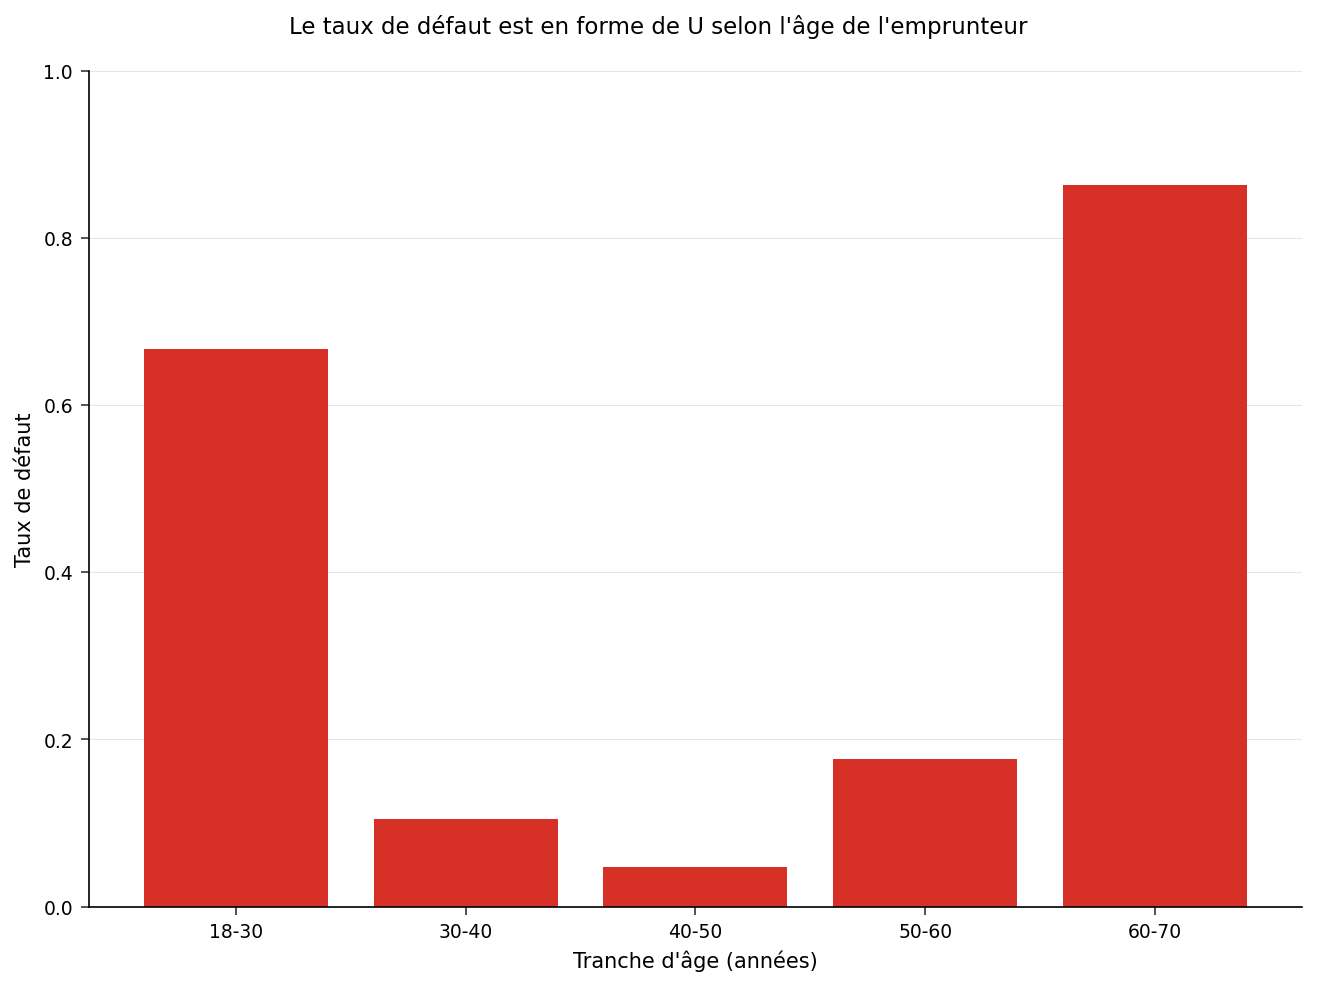

In [4]:
ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=age_rate noautolegend;
   TITRE "Le taux de défaut est en forme de U selon l'âge de l'emprunteur";
   VBAR age_band / RESPONSE=def_rate fillattrs=(color=cxd73027);
   YAXIS ÉTIQUETTE="Taux de défaut" VALUES=(0 JUSQU_À 1 PAR 0.2) grid;
   XAXIS ÉTIQUETTE="Tranche d'âge (années)";
EXÉCUTER;

TITRE;
ODS GRAPHICS OFF;

### Le risque dérive vers le haut avec l'endettement

Les bandes dette/revenu tendent vers le haut — les emprunteurs les plus endettés font défaut le plus souvent — cohérent avec le lissage DTI dominant dans le modèle. Les bandes intermédiaires sont bruitées à cette taille d'échantillon, soulignant pourquoi la spline ajustée est un guide plus stable que n'importe quel seuil tracé à la main.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=dti_rate

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


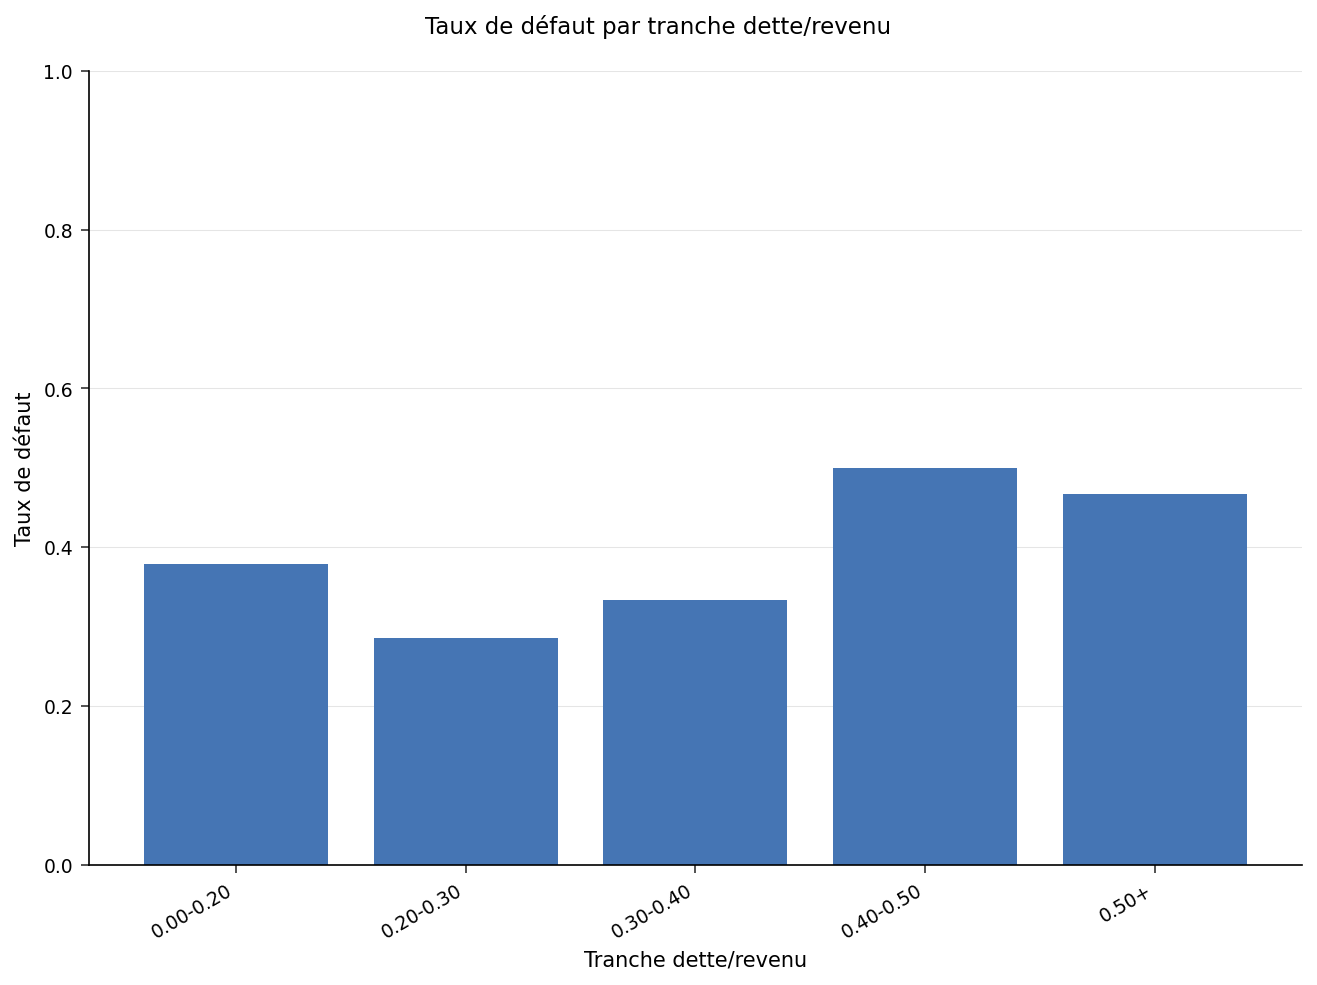

In [5]:
ODS GRAPHICS SUR;

PROCÉDURE SGPLOT DONNÉES=dti_rate noautolegend;
   TITRE "Taux de défaut par tranche dette/revenu";
   VBAR dti_band / RESPONSE=def_rate fillattrs=(color=cx4575b4);
   YAXIS ÉTIQUETTE="Taux de défaut" VALUES=(0 JUSQU_À 1 PAR 0.2) grid;
   XAXIS ÉTIQUETTE="Tranche dette/revenu";
EXÉCUTER;

TITRE;
ODS GRAPHICS OFF;

## Interpréter les résultats

`PROC GAM` a retrouvé la structure non linéaire que nous avions intégrée au portefeuille synthétique sans aucune discrétisation manuelle ni terme polynomial :

- **Ajustement global solide** - le modèle additif à splines fait passer la déviance de 133.75 à 61.69 (une réduction de 72.06) pour un AIC de modèle de 81.69, sur un portefeuille au taux de défaut de base de 39 %.
- **L'endettement domine** - la spline dette/revenu porte le plus grand coefficient (4.34) des trois termes, désignant le DTI comme le principal moteur du log-odds ajusté.
- **Courbure selon l'âge** - la discrétisation du résultat brut confirme un U d'école : 66.7 % de défaut dans la bande des moins de 30 ans, un creux de 4.8 % à 40-50, et 86.4 % pour la bande des 60 ans et plus — la forme qu'une spline cubique capture naturellement mais qu'un unique terme d'âge linéaire manquerait entièrement.
- **Honnête sur le bruit** - à 100 prêts, les taux par bande dette/revenu oscillent, ce qui plaide précisément en faveur d'une estimation lissée plutôt que d'un seuil dur choisi à la main.

**Pourquoi cela compte pour la banque :** les splines additives offrent à une équipe de risque un moyen rapide et automatique de détecter où une relation est véritablement non linéaire avant de s'engager sur une grille de score de production. Les lissages ajustés sont directement interprétables comme des courbes de risque — une prime d'âge jeune-et-âgé, une rampe d'endettement — et la déviance et l'AIC quantifient ce que cette flexibilité apporte par rapport à un modèle linéaire plat.